# SNCF monthly TGV regularity
## Exploratory notebook

This notebook serves as the first exploratory steps into understanding and visualising the data in our data set.

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset
df = pd.read_csv("../data/regularite-mensuelle-tgv-aqst.csv", sep=";") # csv is separated with ';'

In [3]:
df.head()
df.info()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
display(df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 12544 entries, 0 to 12543
Data columns (total 26 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   Date                                                                                         12544 non-null  str    
 1   Service                                                                                      12544 non-null  str    
 2   Gare de départ                                                                               12544 non-null  str    
 3   Gare d'arrivée                                                                               12544 non-null  str    
 4   Durée moyenne du trajet                                                                      12544 non-null  int64  
 5   Nombre de circulations prévues             

,count,mean,std,min,25%,50%,75%,max
Durée moyenne du trajet,12544.0,170.628508,87.730733,0.000000,99.000000,163.000000,223.000000,786.000000
Nombre de circulations prévues,12544.0,272.623884,183.559230,0.000000,151.000000,230.000000,362.000000,1100.000000
Nombre de trains annulés,12544.0,8.407685,22.089205,0.000000,0.000000,2.000000,7.000000,297.000000
Commentaire annulations,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nombre de trains en retard au départ,12544.0,86.219866,88.428503,0.000000,22.000000,52.000000,126.000000,596.000000
Retard moyen des trains en retard au départ,12544.0,12.499854,11.660090,0.000000,6.346596,10.560933,16.101225,316.188095
Retard moyen de tous les trains au départ,12544.0,3.175135,5.054562,-229.269444,1.226076,2.368000,4.031985,115.047390
Commentaire retards au départ,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nombre de trains en retard à l'arrivée,12544.0,38.243304,31.826539,0.000000,16.000000,30.000000,52.000000,376.000000
Retard moyen des trains en retard à l'arrivée,12544.0,35.471909,15.605191,-40.109259,25.958062,33.777423,42.776681,299.600000


## Data clean-up

The first step is to clean up our data; to make sure that the values in our dataset are feasible.
As such, we can already spot multiple issues:
    - Negative or null values for feature "Durée moyenne du trajet"
    - Negative values for "Retard moyen de tous les trains au départ"
    - Negative values for "Retard moyen des trains en retard à l'arrivée"
    - Negative values for "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)"
    - Negative values for "Nombre trains en retard > 30min"

Their are also values which seem suspicious, but for which we cannot tell with certainty if they are errors/outliers, for now:
    - "Retard moyen des trains en retard au départ" whose max value is 316, meaning that on average, train on this itinerary are 5 hours late
    - Same thing for "Retard moyen de tous les trains au départ"
    - same thing for "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)"
    - All percentages at 100% ("Prct retard pour causes externes", etc.)
  


### Numerical features

In [4]:
# Remove impossible values
df_cleaned = df[
    (df["Durée moyenne du trajet"] > 0)
    & (df["Retard moyen de tous les trains au départ"] >= 0)
    & (df["Retard moyen des trains en retard à l'arrivée"] >= 0)
    & (df["Nombre trains en retard > 30min"] >= 0)
    & (df["Retard moyen trains en retard > 15 (si liaison concurrencée par vol)"] >= 0)
    & (df["Retard moyen de tous les trains à l\'arrivée"] >= 0)
].copy().reset_index(drop=True)

display(df_cleaned.describe().T)


,count,mean,std,min,25%,50%,75%,max
Durée moyenne du trajet,12151.0,170.910625,86.470781,45.0,100.000000,163.000000,223.000000,564.000000
Nombre de circulations prévues,12151.0,276.962637,182.645022,2.0,156.000000,234.000000,368.500000,1100.000000
Nombre de trains annulés,12151.0,8.272241,21.879124,0.0,0.000000,2.000000,6.000000,297.000000
Commentaire annulations,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nombre de trains en retard au départ,12151.0,87.889474,88.618806,0.0,23.000000,54.000000,128.000000,596.000000
Retard moyen des trains en retard au départ,12151.0,12.749709,11.720730,0.0,6.589925,10.789167,16.292455,316.188095
Retard moyen de tous les trains au départ,12151.0,3.307609,4.341445,0.0,1.304278,2.432328,4.085088,115.047390
Commentaire retards au départ,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nombre de trains en retard à l'arrivée,12151.0,39.069542,31.756230,0.0,17.000000,31.000000,53.000000,376.000000
Retard moyen des trains en retard à l'arrivée,12151.0,35.907453,15.227923,0.0,26.306244,34.001235,43.007099,299.600000


We can also identify certain outliers visually

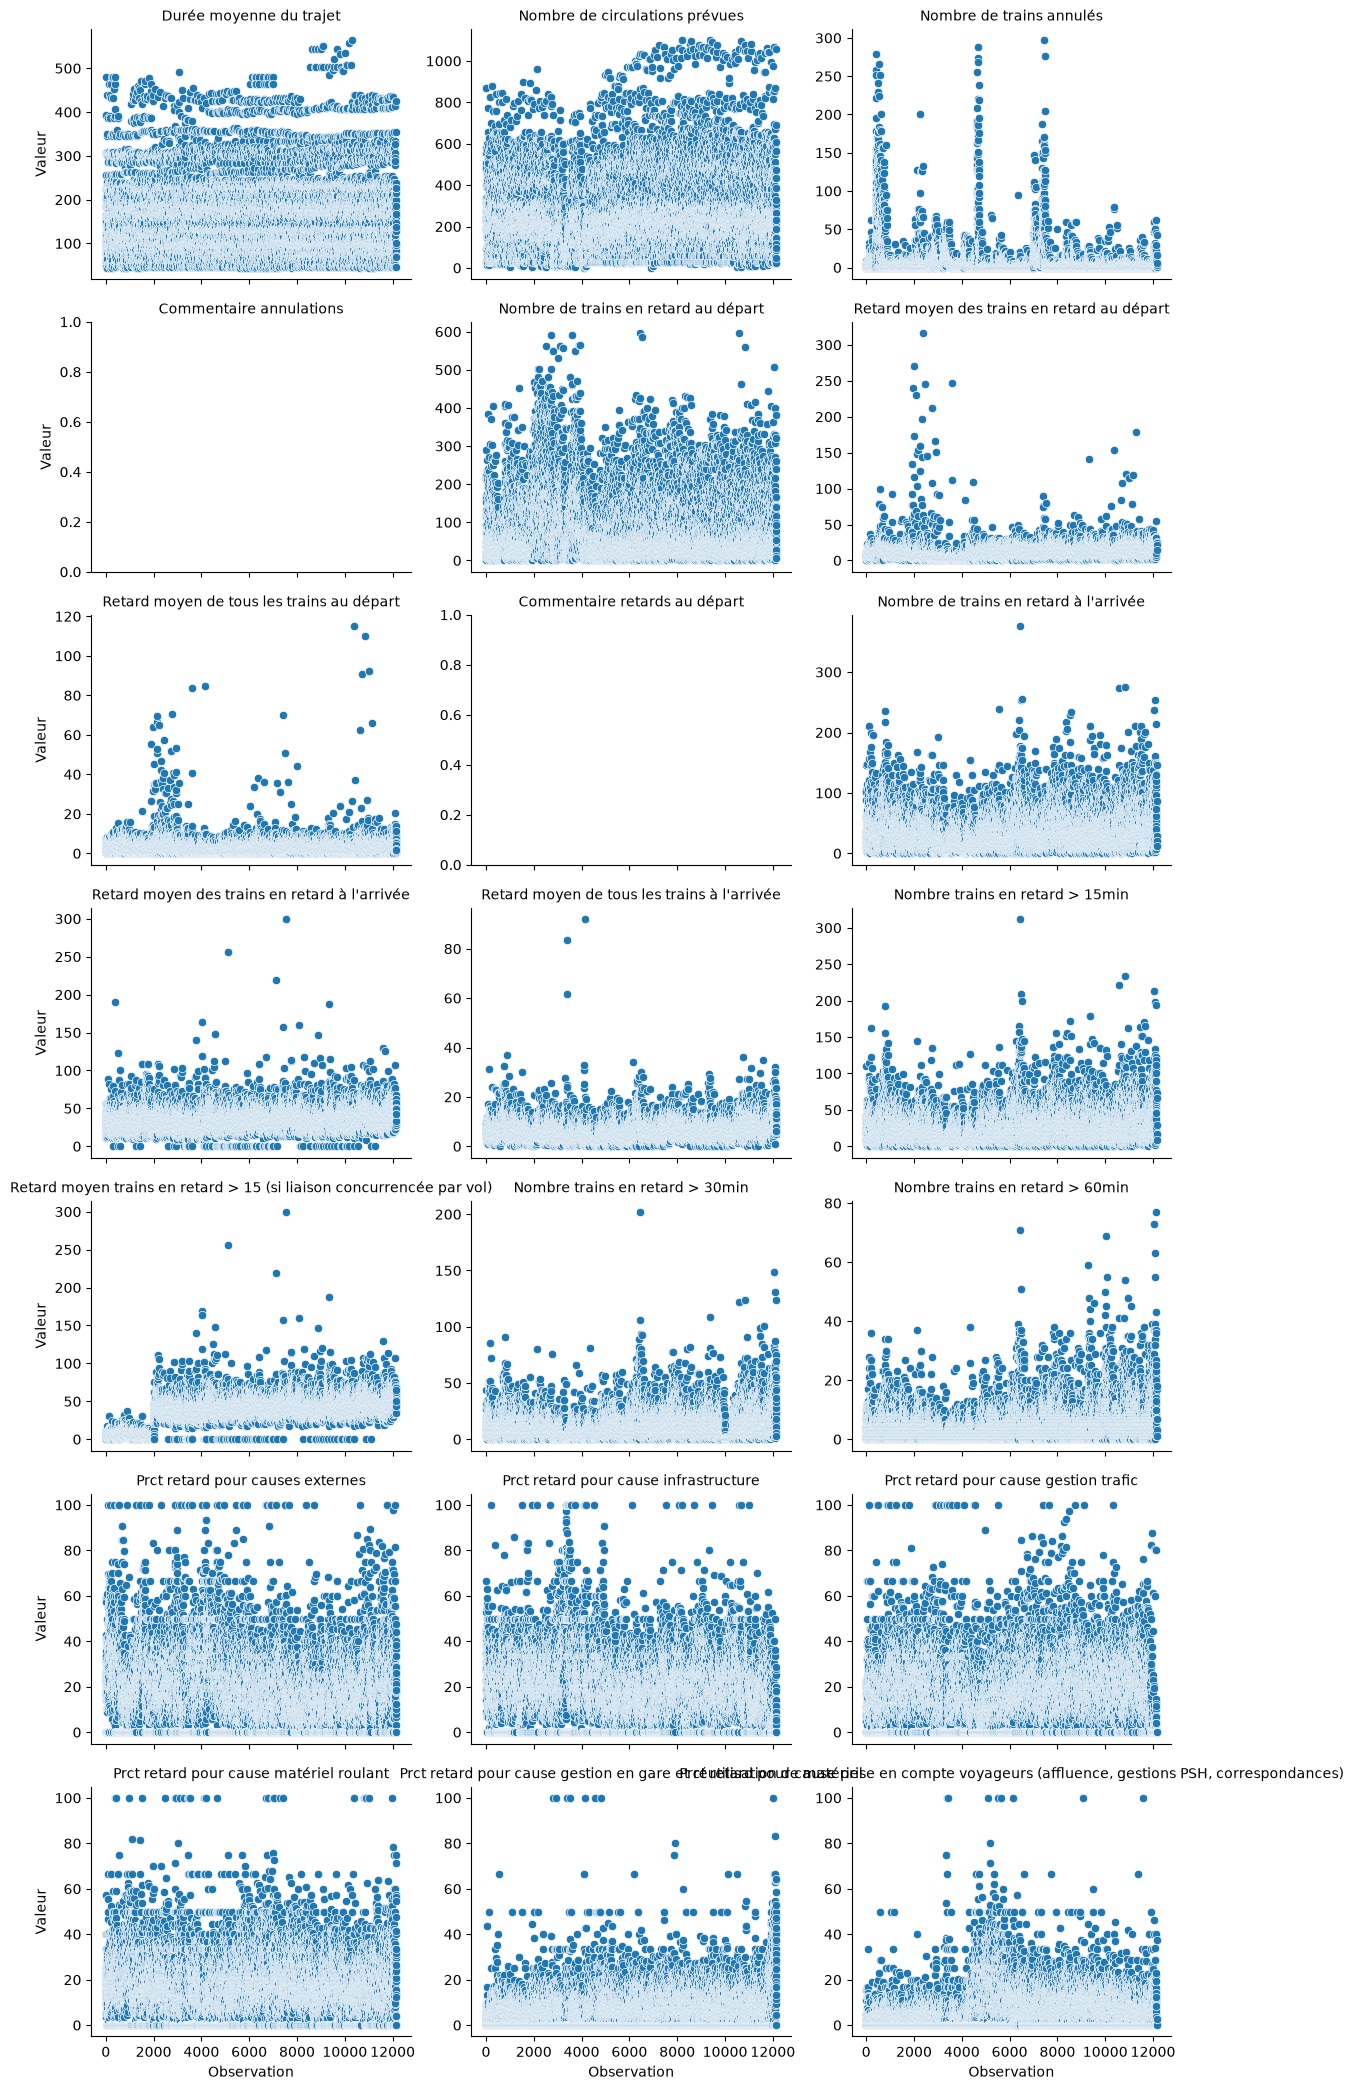

In [5]:

# Keep only numerical columns
numeric_cols = df_cleaned.select_dtypes(include="number").columns

# Convert to long format
df_plot = (
    df_cleaned[numeric_cols]
    .reset_index(drop=True)
    .reset_index(names="observation")
    .melt(
        id_vars="observation",
        var_name="variable",
        value_name="value"
    )
)

# Grid of scatter plots
g = sns.relplot(
    data=df_plot,
    x="observation",
    y="value",
    col="variable",
    col_wrap=3,
    kind="scatter",
    facet_kws={"sharey": False},
    height=3,
    aspect=1.3
)

g.set_titles("{col_name}")
g.set_axis_labels("Observation", "Valeur")


### Categorical features

We must also take a look at our categorical features, to check for inconsistencie, and convert to more convenient formats is necessary (such as datetime)

In [6]:

# Non-numerical variables
categorical_summary = (
    df.select_dtypes(exclude="number")
      .apply(
          lambda col: pd.Series({
              "n_unique": col.nunique(dropna=True),
              "unique_values": col.dropna().unique().tolist()
          })
      )
      .T
)

display(categorical_summary)

,n_unique,unique_values
Date,102,"[2018-01, 2018-02, 2018-03, 2018-04, 2018-05, ..."
Service,2,"[National, International]"
Gare de départ,59,"[BORDEAUX ST JEAN, LE MANS, PARIS MONTPARNASSE..."
Gare d'arrivée,59,"[PARIS MONTPARNASSE, LA ROCHELLE VILLE, NANTES..."
Commentaire retards à l'arrivée,302,"[Ce mois-ci, l'OD a été touchée par les incide..."


In [7]:
# convert date strings into dateTime obj
print(f"DataSet dates as a string: {df["Date"][0]}")
df_cleaned["Date"] = pd.to_datetime(df["Date"]).reset_index(drop=True)
print(f"DataSet dates as a DateTime: {df_cleaned["Date"][0]}")

DataSet dates as a string: 2018-01
DataSet dates as a DateTime: 2018-01-01 00:00:00


In [8]:
# there are also errors in national/international services
# example:
i = 1209
print(f"Service: International, ligne {i}")
print(f"Gare de depart: {df_cleaned['Gare de départ'][i]}")
print(f"Gare d'arrivée: {df_cleaned["Gare d'arrivée"][i]}")
print(" - - - -- - - - - - -- ")

# cleanup:
internation_stations = [
    "ITALIE",
    "BARCELONA",
    "MADRID",
    "GENEVE",
    "LAUSANNE",
    "ZURICH",
    "STUTTGART",
    "FRANCFORT"
    ]

for i, service in enumerate(df_cleaned['Service']):
    if service == "National" and ((df_cleaned['Gare de départ'][i] in internation_stations) or (df_cleaned["Gare d'arrivée"][i] in internation_stations)):
        print(f"Service: {service}, rang {i}")
        print(f"Gare de depart: {df_cleaned['Gare de départ'][i]}")
        print(f"Gare d'arrivée: {df_cleaned["Gare d'arrivée"][i]}")
        # replace erronous value
        df_cleaned['Service'] = "International"


Service: International, ligne 1209
Gare de depart: GENEVE
Gare d'arrivée: PARIS LYON
 - - - -- - - - - - -- 


Service: National, rang 11106
Gare de depart: PARIS LYON
Gare d'arrivée: BARCELONA
Service: National, rang 11140
Gare de depart: BARCELONA
Gare d'arrivée: PARIS LYON
Service: National, rang 11205
Gare de depart: PARIS LYON
Gare d'arrivée: BARCELONA
Service: National, rang 11287
Gare de depart: BARCELONA
Gare d'arrivée: PARIS LYON
Service: National, rang 11313
Gare de depart: BARCELONA
Gare d'arrivée: PARIS LYON
Service: National, rang 11323
Gare de depart: PARIS LYON
Gare d'arrivée: BARCELONA
Service: National, rang 11522
Gare de depart: BARCELONA
Gare d'arrivée: PARIS LYON
Service: National, rang 11535
Gare de depart: PARIS LYON
Gare d'arrivée: BARCELONA
Service: National, rang 11573
Gare de depart: BARCELONA
Gare d'arrivée: PARIS LYON
Service: National, rang 11588
Gare de depart: PARIS LYON
Gare d'arrivée: BARCELONA
Service: National, rang 11672
Gare de depart: BARCELONA
Gare d'arrivée: PARIS LYON
Service: National, rang 11752
Gare de depart: PARIS LYON
Gare d'arrivée: BARCELONA
Serv

## EDA

## 1 - Distributions

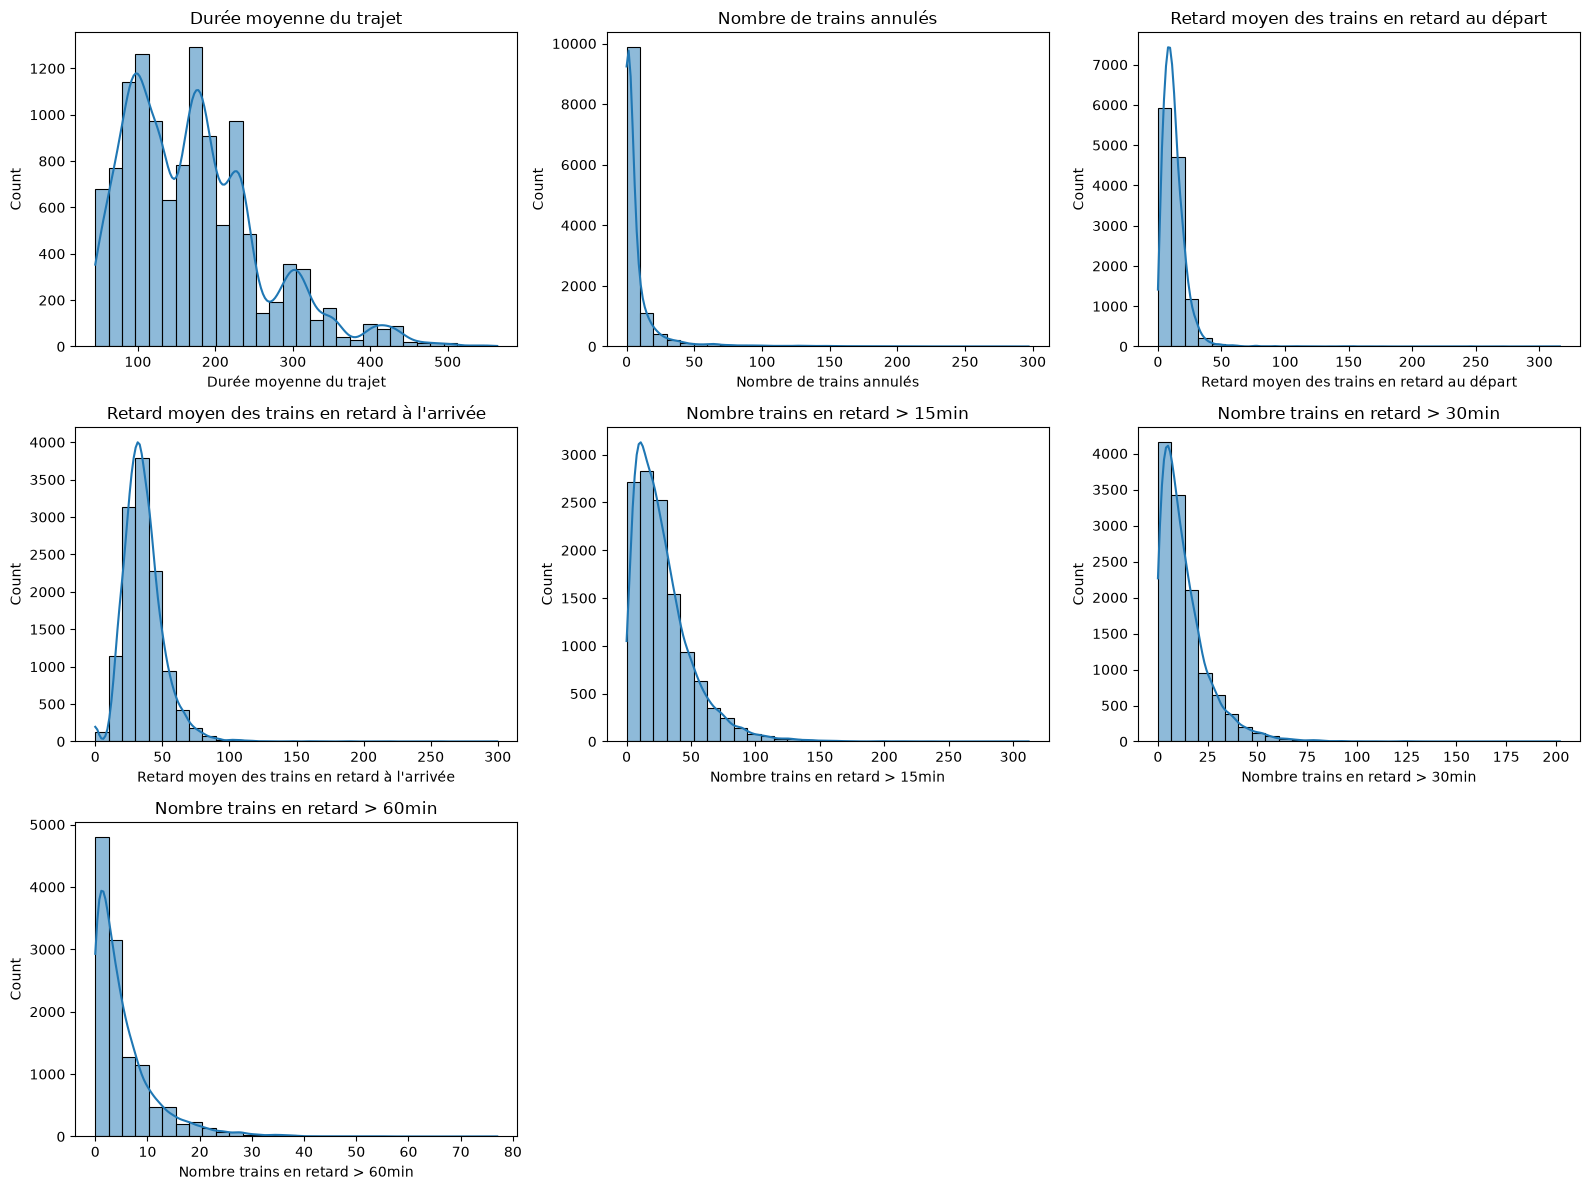

In [9]:
cols = [
    "Durée moyenne du trajet",
    "Nombre de trains annulés",
    "Retard moyen des trains en retard au départ",
    "Retard moyen des trains en retard à l'arrivée",
    "Nombre trains en retard > 15min",
    "Nombre trains en retard > 30min",
    "Nombre trains en retard > 60min",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.histplot(
        data=df_cleaned,
        x=col,
        bins=30,
        kde=True,
        ax=ax
    )
    ax.set_title(col)

# Remove unused subplot(s)
for ax in axes[len(cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

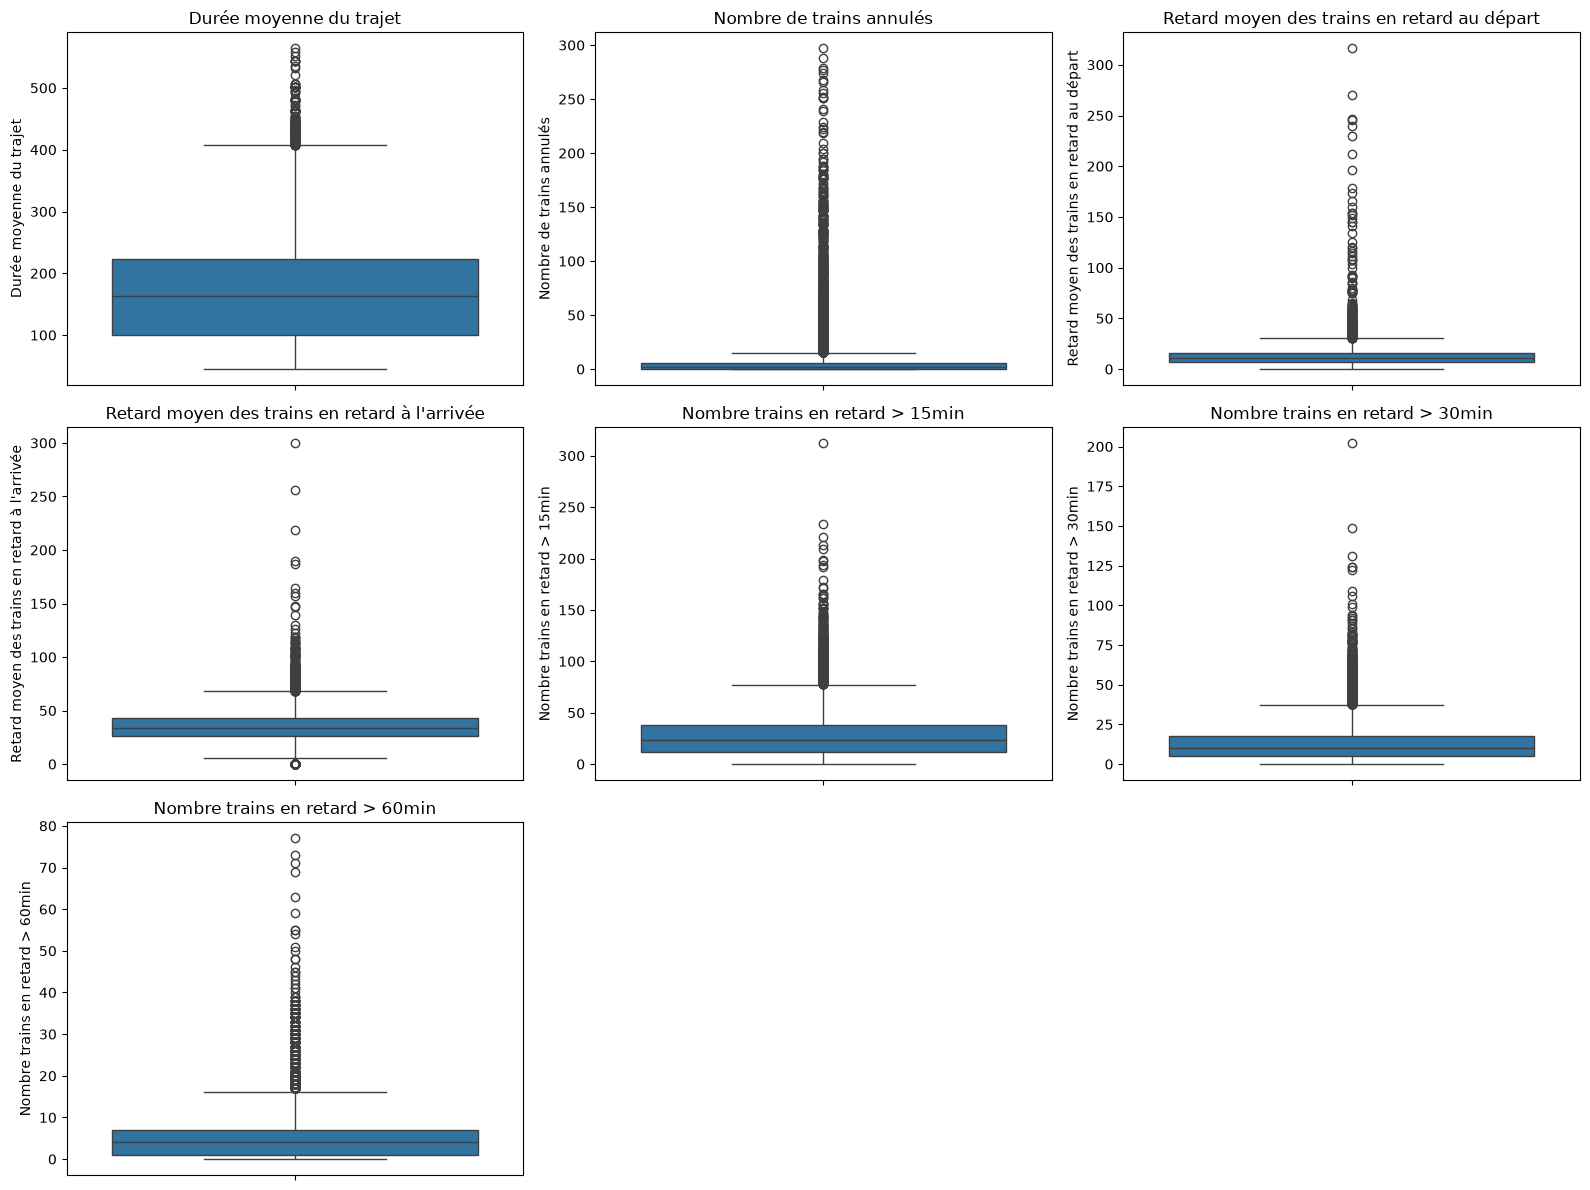

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.boxplot(
        data=df_cleaned,
        y=col,
        ax=ax
    )
    ax.set_title(col)

for ax in axes[len(cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

### 2 - Temporal evolution

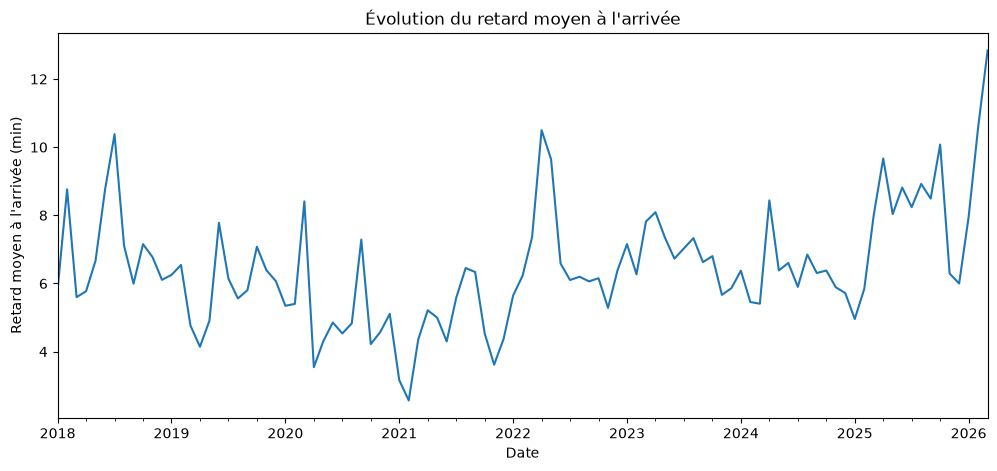

In [11]:
monthly = (
    df_cleaned
    .groupby("Date")["Retard moyen de tous les trains à l'arrivée"]
    .mean()
)

monthly.plot(figsize=(12, 5))

plt.ylabel("Retard moyen à l'arrivée (min)")
plt.title("Évolution du retard moyen à l'arrivée")
plt.show()

7.072368421052631
43
608


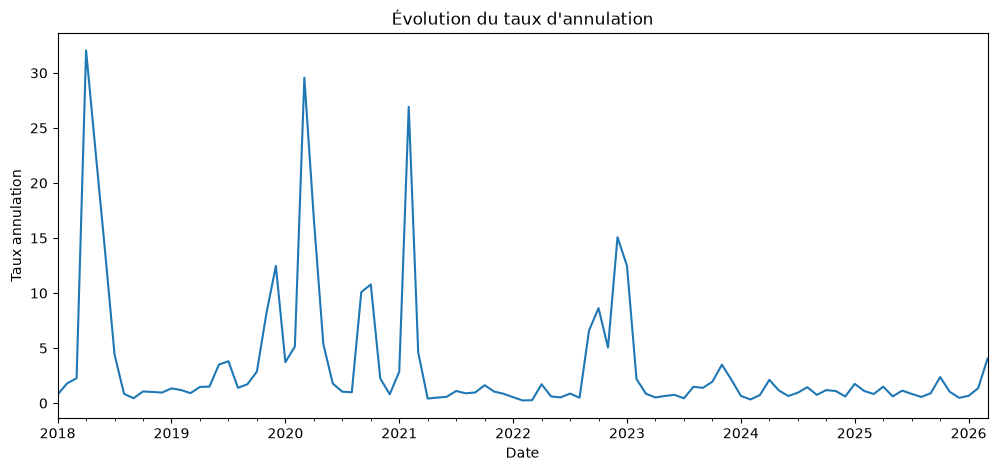

In [ ]:
# create new features that use rates instead of counts
df_cleaned["Taux annulation"] = (df_cleaned["Nombre de trains annulés"] / df_cleaned["Nombre de circulations prévues"] * 100)
df_cleaned["Taux retard arrivée"] = (df_cleaned["Nombre de trains en retard à l'arrivée"] / (df_cleaned["Nombre de circulations prévues"] - df_cleaned["Nombre de trains annulés"]) * 100)

print(df_cleaned["Taux annulation"][12146])
print(df_cleaned["Nombre de trains annulés"][12146])
print(df_cleaned["Nombre de circulations prévues"][12146])

monthly = (
    df_cleaned
    .groupby("Date")["Taux annulation"]
    .mean()
)

monthly.plot(figsize=(12, 5))

plt.ylabel("Taux d'annulation (en %)")
plt.title("Évolution du taux d'annulation (en %)")
plt.show()

### 3. Analyse par liaison

### 4. Relations entre variables


### 5. Causes des retards